# Lab: Random Forests and XGBoost with scikit-learn

In the [theory notes](./23_bias_variance_and_ensemble_models_theory.md), we learned the two fundamental approaches to ensemble learning:
- **Bagging (Random Forests)**: Train many deep, independent trees on bootstrap samples, then **average** their predictions to reduce variance.
- **Boosting (XGBoost)**: Train many shallow, sequential trees where each new tree **corrects the errors** of the previous ones to reduce bias.

In the implementation files, we built a [Random Forest](./24_random_forest_implementation.py) from scratch using bootstrap sampling + random feature subsets, and an [AdaBoost classifier](./25_adaboost_implementation.py) to understand the sequential boosting logic.

**Now it's time to use the real thing.** In this lab, we'll learn how to:

1. Load data and build both a `RandomForestRegressor` and an `XGBRegressor`.
2. **Understand what each model learns** — inspecting individual trees inside the ensemble.
3. **Visualize feature importance** and understand *why* the two models rank features differently.
4. **See the ensemble effect** — how adding more trees progressively improves and stabilizes predictions.
5. **Explore key hyperparameters** for both models.
6. **Understand the Bagging vs. Boosting tradeoff** through a direct visual comparison.
7. Understand **why scaling is NOT required** for tree-based ensembles.

---

## 1. The Dataset

We'll use the **California Housing dataset** — the same regression benchmark from the Regression Trees Lab. The goal is to predict **median house value** for California census block groups based on 8 features (income, house age, rooms, bedrooms, population, occupancy, latitude, longitude).

This dataset is ideal for ensembles because:
- It has **nonlinear relationships** (e.g., income vs. price has a sharp threshold).
- It has **spatial patterns** (coastal vs. inland) that trees can capture through coordinate splits.
- A single regression tree underfits or overfits — ensembles shine here.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 150

In [2]:
# Load the California Housing dataset
housing = fetch_california_housing()

feature_names = list(housing.feature_names)
target_name = housing.target_names[0] if hasattr(housing, 'target_names') else "MedHouseVal"

df = pd.DataFrame(housing.data, columns=feature_names)
df["MedHouseVal"] = housing.target

X = df[feature_names].values
y = df["MedHouseVal"].values

print(f"Dataset: {df.shape[0]} samples, {len(feature_names)} features")
print(f"Target: Median house value (in $100,000s)")
print(f"Target range: ${y.min()*100_000:,.0f} – ${y.max()*100_000:,.0f}")
print()
df.sample(5, random_state=42)

Dataset: 20640 samples, 8 features
Target: Median house value (in $100,000s)
Target range: $14,999 – $500,001



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.47700
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.45800
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,5.00001
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.18600
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.78000


---

## 2. No Scaling Required!

Just like single decision trees, **ensemble tree models do not need feature scaling**.

Why? Because every tree in the ensemble makes decisions using **threshold splits** (e.g., `MedInc > 4.5`), not distances or dot products. Each feature is evaluated independently at each node. A feature ranging 0–15 and one ranging -122 to -114 cause no issues — the tree finds the optimal split point for each.

This applies to both Random Forests (bagging of trees) and XGBoost (boosting of trees).

---

## 3. Random Forest: Bagging with Trees

From the theory:
> *"A Random Forest is a specific type of Bagging applied to Decision Trees, with one extra trick to further reduce correlation between trees: at each split, the algorithm is only allowed to search through a random subset of features."*

scikit-learn's `RandomForestRegressor` key parameters:

| Parameter | What It Does | Default |
|---|---|---|
| `n_estimators` | Number of trees in the forest | 100 |
| `max_depth` | Maximum depth of each tree | `None` (fully grown) |
| `max_features` | Number of features considered at each split | `1.0` (all features for regression) |
| `bootstrap` | Whether to use bootstrap sampling | `True` |
| `random_state` | Seed for reproducibility | `None` |

Let's build one:

In [3]:
# Build and train a Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf.fit(X, y)

print("RandomForestRegressor model ready!")
print(f"  n_estimators: {rf.n_estimators} trees")
print(f"  max_depth: {rf.max_depth}")
print(f"  max_features: {rf.max_features}")
print(f"  bootstrap: {rf.bootstrap}")
print(f"\n📌 The 'model' is {rf.n_estimators} separate decision trees.")
print(f"   Each tree was trained on a bootstrap sample (~63.2% unique samples),")
print(f"   and at each split, only a random subset of features was considered.")

RandomForestRegressor model ready!
  n_estimators: 100 trees
  max_depth: 10
  max_features: 1.0
  bootstrap: True

📌 The 'model' is 100 separate decision trees.
   Each tree was trained on a bootstrap sample (~63.2% unique samples),
   and at each split, only a random subset of features was considered.


---

## 4. Looking Inside the Forest: Individual Trees

A Random Forest stores its individual trees in `.estimators_`. Let's peek at what the individual trees look like and how they differ from each other — this is the "diversity" that makes the ensemble work:

In [4]:
# Inspect the individual trees
print(f"Number of trees: {len(rf.estimators_)}")
print(f"Each tree is a: {type(rf.estimators_[0]).__name__}")
print()

# Compare structure of first 5 trees
print(f"{'Tree':<6} {'Leaves':<10} {'Max Depth':<12} {'Features Used at Root':}")
print("-" * 55)
for i in range(5):
    tree = rf.estimators_[i].tree_
    n_leaves = tree.n_leaves
    depth = tree.max_depth
    root_feature = feature_names[tree.feature[0]]
    root_threshold = tree.threshold[0]
    print(f"{i:<6} {n_leaves:<10} {depth:<12} {root_feature} <= {root_threshold:.2f}")

print(f"\n📌 Notice: Different trees split on DIFFERENT features at the root!")
print(f"   This is the 'random feature selection' at work.")
print(f"   It forces diversity among trees, which makes averaging more powerful.")

Number of trees: 100
Each tree is a: DecisionTreeRegressor

Tree   Leaves     Max Depth    Features Used at Root
-------------------------------------------------------
0      706        10           MedInc <= 5.59
1      732        10           MedInc <= 5.10
2      745        10           MedInc <= 5.09
3      689        10           MedInc <= 5.13
4      716        10           MedInc <= 5.02

📌 Notice: Different trees split on DIFFERENT features at the root!
   This is the 'random feature selection' at work.
   It forces diversity among trees, which makes averaging more powerful.


---

## 5. The Ensemble Effect: More Trees → More Stable Predictions

The theory says:
> *"If you have many models that are slightly better than random guessing, and their errors are uncorrelated, averaging them produces a result that is much more accurate than any individual model."*

Let's see this in action. We'll track how predictions change as we add more and more trees:

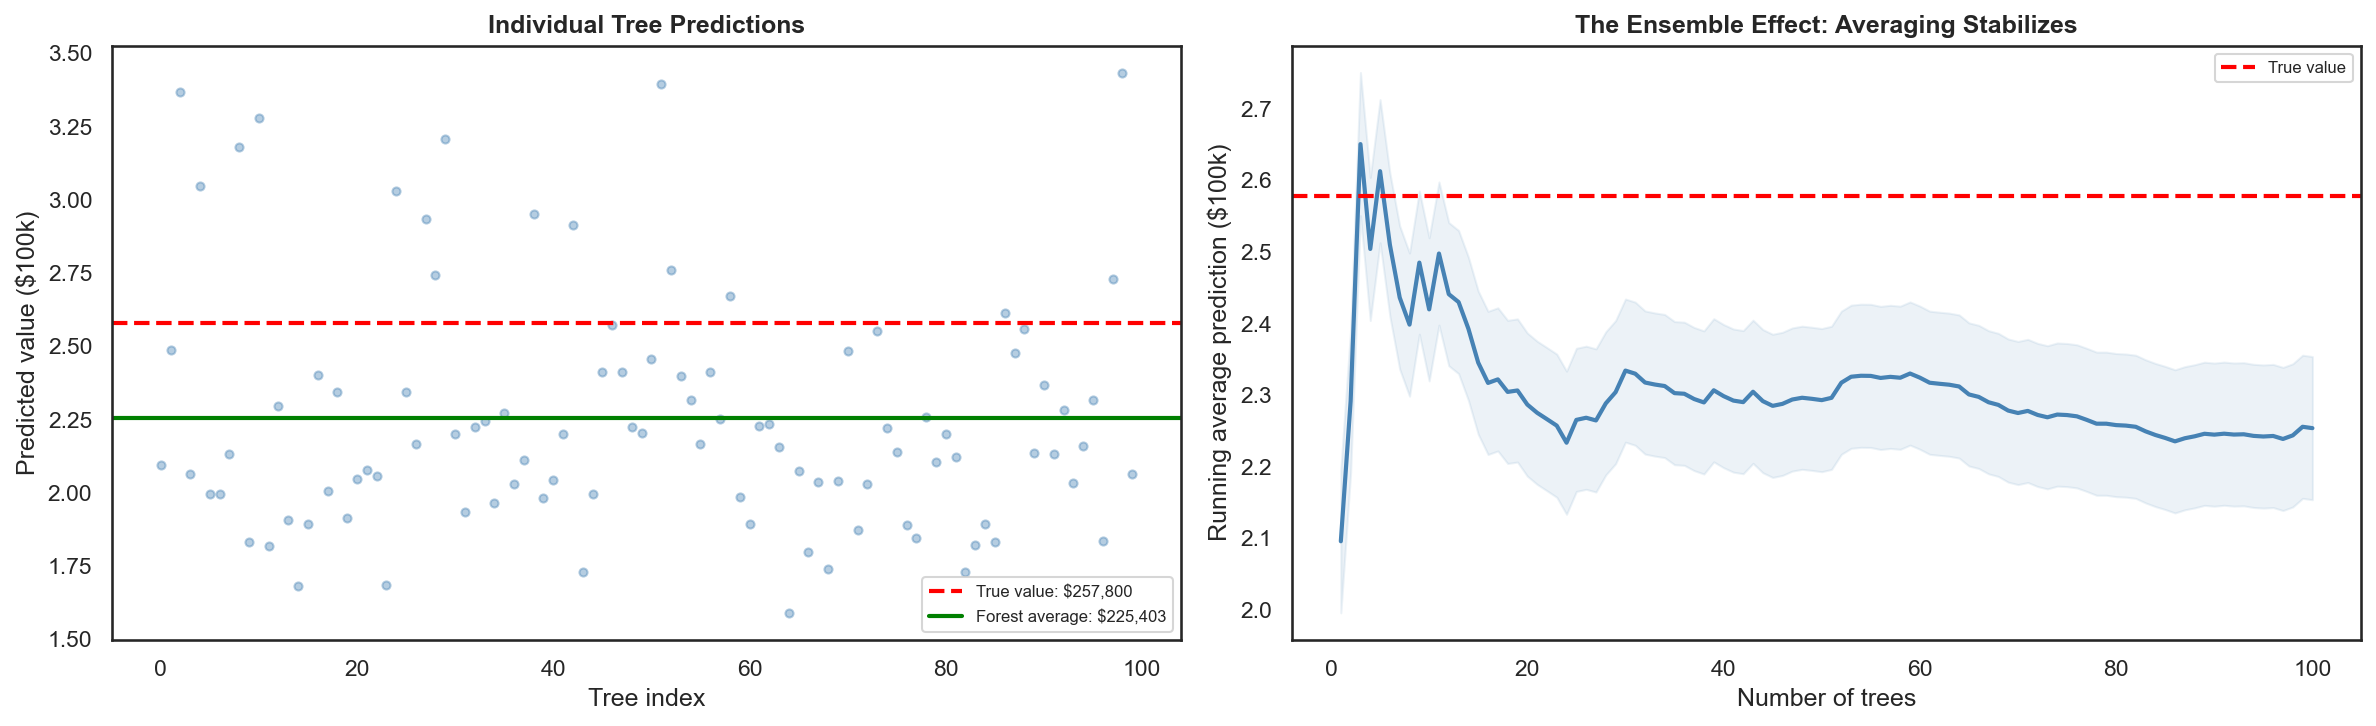

📌 Left: Each tree gives a different prediction — they disagree a lot!
   Individual tree std: $40,521
   Right: But the running average converges quickly.
   After ~30 trees, adding more barely changes the prediction.
   This is why Random Forests are so stable — they average out the noise.


In [5]:
# Pick a sample to trace
sample_idx = 100
sample = X[sample_idx:sample_idx+1]
true_val = y[sample_idx]

# Get each individual tree's prediction
individual_preds = np.array([tree.predict(sample)[0] for tree in rf.estimators_])

# Running average as we add trees
cumulative_avg = np.cumsum(individual_preds) / np.arange(1, len(individual_preds) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Individual tree predictions (scatter)
axes[0].scatter(range(len(individual_preds)), individual_preds, alpha=0.4, s=15, color="steelblue")
axes[0].axhline(y=true_val, color="red", linestyle="--", linewidth=2, label=f"True value: ${true_val*100_000:,.0f}")
axes[0].axhline(y=individual_preds.mean(), color="green", linestyle="-", linewidth=2,
                label=f"Forest average: ${individual_preds.mean()*100_000:,.0f}")
axes[0].set_xlabel("Tree index")
axes[0].set_ylabel("Predicted value ($100k)")
axes[0].set_title("Individual Tree Predictions", fontweight="bold")
axes[0].legend(fontsize=8)

# Right: Running average as trees are added
axes[1].plot(range(1, len(cumulative_avg) + 1), cumulative_avg, color="steelblue", linewidth=2)
axes[1].axhline(y=true_val, color="red", linestyle="--", linewidth=2, label=f"True value")
axes[1].fill_between(range(1, len(cumulative_avg) + 1),
                     cumulative_avg - 0.1, cumulative_avg + 0.1,
                     alpha=0.1, color="steelblue")
axes[1].set_xlabel("Number of trees")
axes[1].set_ylabel("Running average prediction ($100k)")
axes[1].set_title("The Ensemble Effect: Averaging Stabilizes", fontweight="bold")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"📌 Left: Each tree gives a different prediction — they disagree a lot!")
print(f"   Individual tree std: ${individual_preds.std()*100_000:,.0f}")
print(f"   Right: But the running average converges quickly.")
print(f"   After ~30 trees, adding more barely changes the prediction.")
print(f"   This is why Random Forests are so stable — they average out the noise.")

---

## 6. XGBoost: Gradient Boosting with Trees

From the theory:
> *"Gradient Boosting: Instead of reweighting data points, each new model tries to predict the residuals (errors) of the previous model."*
> *"XGBoost: An optimized, highly efficient implementation of Gradient Boosting."*

`XGBRegressor` key parameters:

| Parameter | What It Does | Default |
|---|---|---|
| `n_estimators` | Number of boosting rounds (trees) | 100 |
| `max_depth` | Maximum depth of each tree (usually shallow!) | 6 |
| `learning_rate` | Shrinkage factor — how much each tree contributes | 0.3 |
| `subsample` | Fraction of samples used per tree | 1.0 |
| `colsample_bytree` | Fraction of features used per tree | 1.0 |

Key difference from Random Forest: XGBoost uses **shallow trees** (weak learners) trained **sequentially**, while RF uses **deep trees** trained **in parallel**.

In [6]:
# Build and train XGBoost
xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
xgb.fit(X, y)

print("XGBRegressor model ready!")
print(f"  n_estimators: {xgb.n_estimators} boosting rounds")
print(f"  max_depth: {xgb.max_depth}")
print(f"  learning_rate: {xgb.learning_rate}")
print(f"\n📌 Unlike RF, these 100 trees are NOT independent.")
print(f"   Tree 2 was trained to fix the errors of Tree 1.")
print(f"   Tree 3 was trained to fix the remaining errors of Trees 1+2.")
print(f"   And so on — each tree 'boosts' the previous ensemble.")

XGBRegressor model ready!
  n_estimators: 100 boosting rounds
  max_depth: 6
  learning_rate: 0.1

📌 Unlike RF, these 100 trees are NOT independent.
   Tree 2 was trained to fix the errors of Tree 1.
   Tree 3 was trained to fix the remaining errors of Trees 1+2.
   And so on — each tree 'boosts' the previous ensemble.


---

## 7. Visualizing the Boosting Process: Error Correction

Let's trace how XGBoost builds up its prediction **round by round**. The `ntree_limit` / `iteration_range` parameter lets us see the prediction after N boosting rounds:

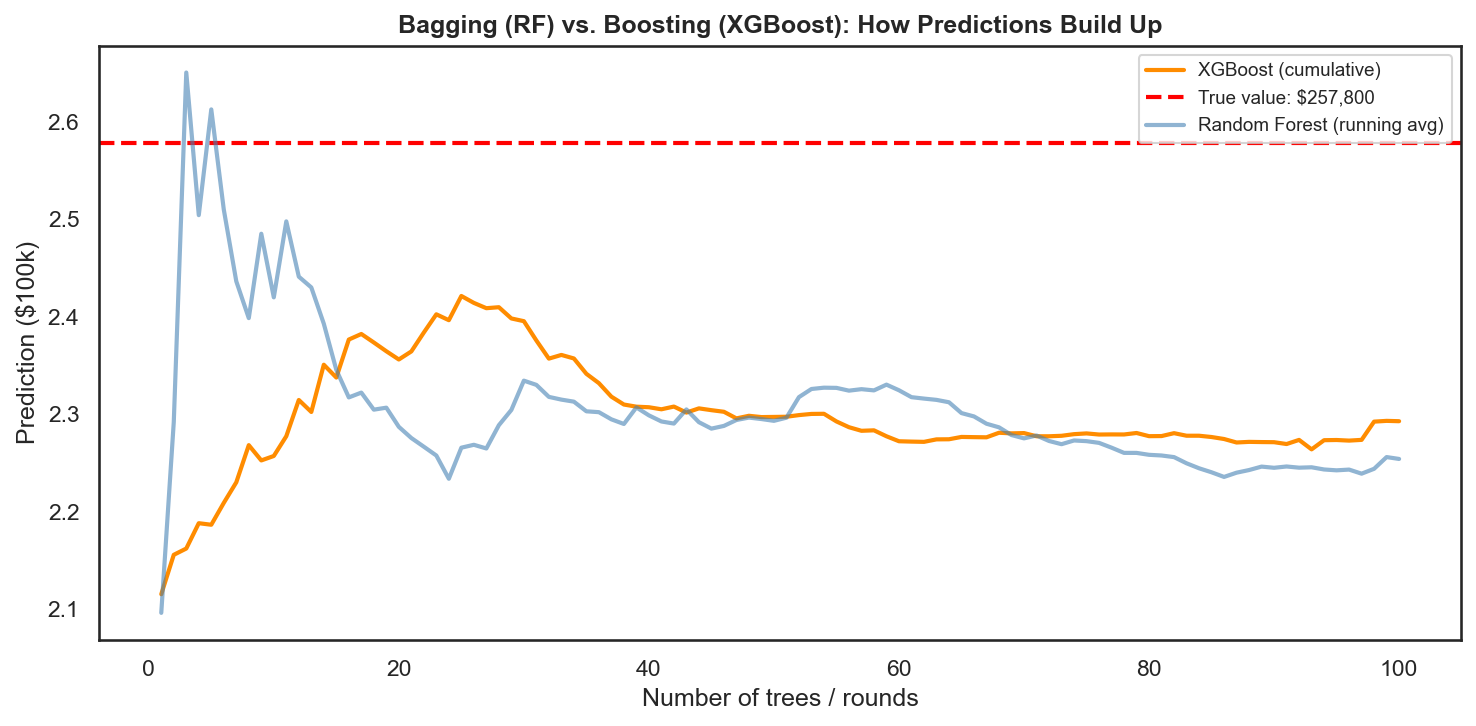

📌 RF (blue): The running average stabilizes quickly — adding more trees
   just reduces noise, the prediction barely changes after ~30 trees.
   XGBoost (orange): The prediction improves CONTINUOUSLY — each round
   corrects the residual error of the previous rounds.
   This is the fundamental difference between Bagging and Boosting.


In [7]:
# Track XGBoost's prediction as boosting rounds increase
sample = X[sample_idx:sample_idx+1]

xgb_progressive = []
for n_rounds in range(1, 101):
    pred = xgb.predict(sample, iteration_range=(0, n_rounds))[0]
    xgb_progressive.append(pred)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 101), xgb_progressive, color="darkorange", linewidth=2, label="XGBoost (cumulative)")
ax.axhline(y=true_val, color="red", linestyle="--", linewidth=2, label=f"True value: ${true_val*100_000:,.0f}")

# Also overlay RF's running average for comparison
ax.plot(range(1, 101), cumulative_avg, color="steelblue", linewidth=2, alpha=0.6, label="Random Forest (running avg)")

ax.set_xlabel("Number of trees / rounds")
ax.set_ylabel("Prediction ($100k)")
ax.set_title("Bagging (RF) vs. Boosting (XGBoost): How Predictions Build Up", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("📌 RF (blue): The running average stabilizes quickly — adding more trees")
print("   just reduces noise, the prediction barely changes after ~30 trees.")
print("   XGBoost (orange): The prediction improves CONTINUOUSLY — each round")
print("   corrects the residual error of the previous rounds.")
print("   This is the fundamental difference between Bagging and Boosting.")

---

## 8. Feature Importance: Which Features Drive Predictions?

Both ensemble models provide **feature importance scores**. But they measure different things:

- **Random Forest**: Importance = total reduction in impurity (MSE) across ALL splits in ALL trees that use this feature.
- **XGBoost**: By default, importance = number of times a feature is used as a split across all trees ("weight"). Can also use "gain" (total MSE reduction).

Let's compare them side-by-side:

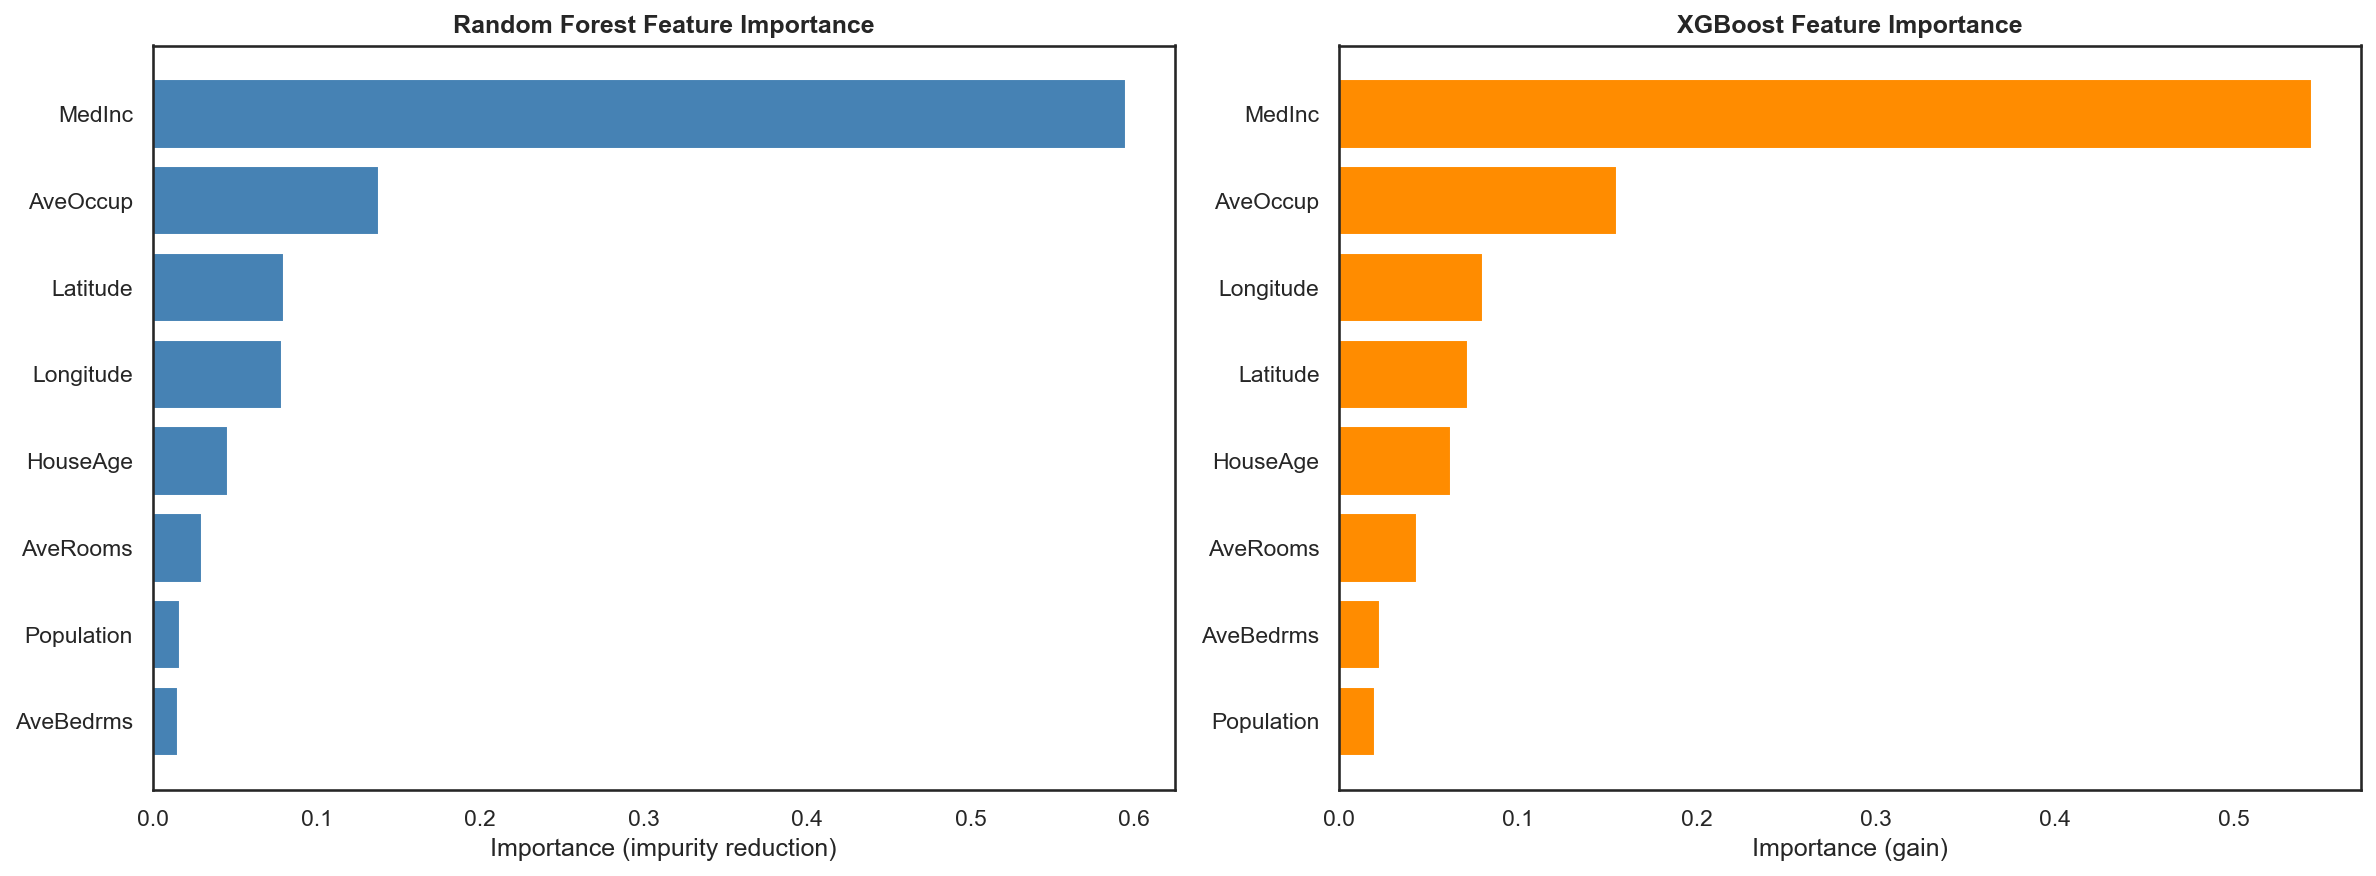

Feature Importance Rankings:
Feature         RF Rank    XGB Rank  
-----------------------------------
MedInc          1          1         
HouseAge        5          5         
AveRooms        6          6         
AveBedrms       8          7         
Population      7          8         
AveOccup        2          2         
Latitude        3          4         
Longitude       4          3         

📌 Both models agree that MedInc (median income) is the #1 predictor.
   But they may disagree on the lower-ranked features.
   This is normal — RF and XGBoost use features differently.


In [8]:
# Get feature importances
rf_importance = rf.feature_importances_
xgb_importance = xgb.feature_importances_  # uses 'gain' by default in sklearn interface

# Create a side-by-side comparison
fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Random Forest": rf_importance,
    "XGBoost": xgb_importance
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
rf_sorted = fi_df.sort_values("Random Forest", ascending=True)
axes[0].barh(rf_sorted["Feature"], rf_sorted["Random Forest"], color="steelblue")
axes[0].set_title("Random Forest Feature Importance", fontweight="bold")
axes[0].set_xlabel("Importance (impurity reduction)")

# XGBoost
xgb_sorted = fi_df.sort_values("XGBoost", ascending=True)
axes[1].barh(xgb_sorted["Feature"], xgb_sorted["XGBoost"], color="darkorange")
axes[1].set_title("XGBoost Feature Importance", fontweight="bold")
axes[1].set_xlabel("Importance (gain)")

plt.tight_layout()
plt.show()

# Show ranking comparison
print("Feature Importance Rankings:")
print(f"{'Feature':<15} {'RF Rank':<10} {'XGB Rank':<10}")
print("-" * 35)
rf_ranks = fi_df["Random Forest"].rank(ascending=False).astype(int)
xgb_ranks = fi_df["XGBoost"].rank(ascending=False).astype(int)
for i, feat in enumerate(feature_names):
    print(f"{feat:<15} {rf_ranks.iloc[i]:<10} {xgb_ranks.iloc[i]:<10}")

print(f"\n📌 Both models agree that MedInc (median income) is the #1 predictor.")
print(f"   But they may disagree on the lower-ranked features.")
print(f"   This is normal — RF and XGBoost use features differently.")

---

## 9. Exploring Key Hyperparameters

### 9.1 Random Forest: `n_estimators` (Number of Trees)

The theory implies that more trees → better averaging → lower variance. But is there diminishing returns? Let's visualize the relationship between the number of trees and the spread of individual tree predictions:

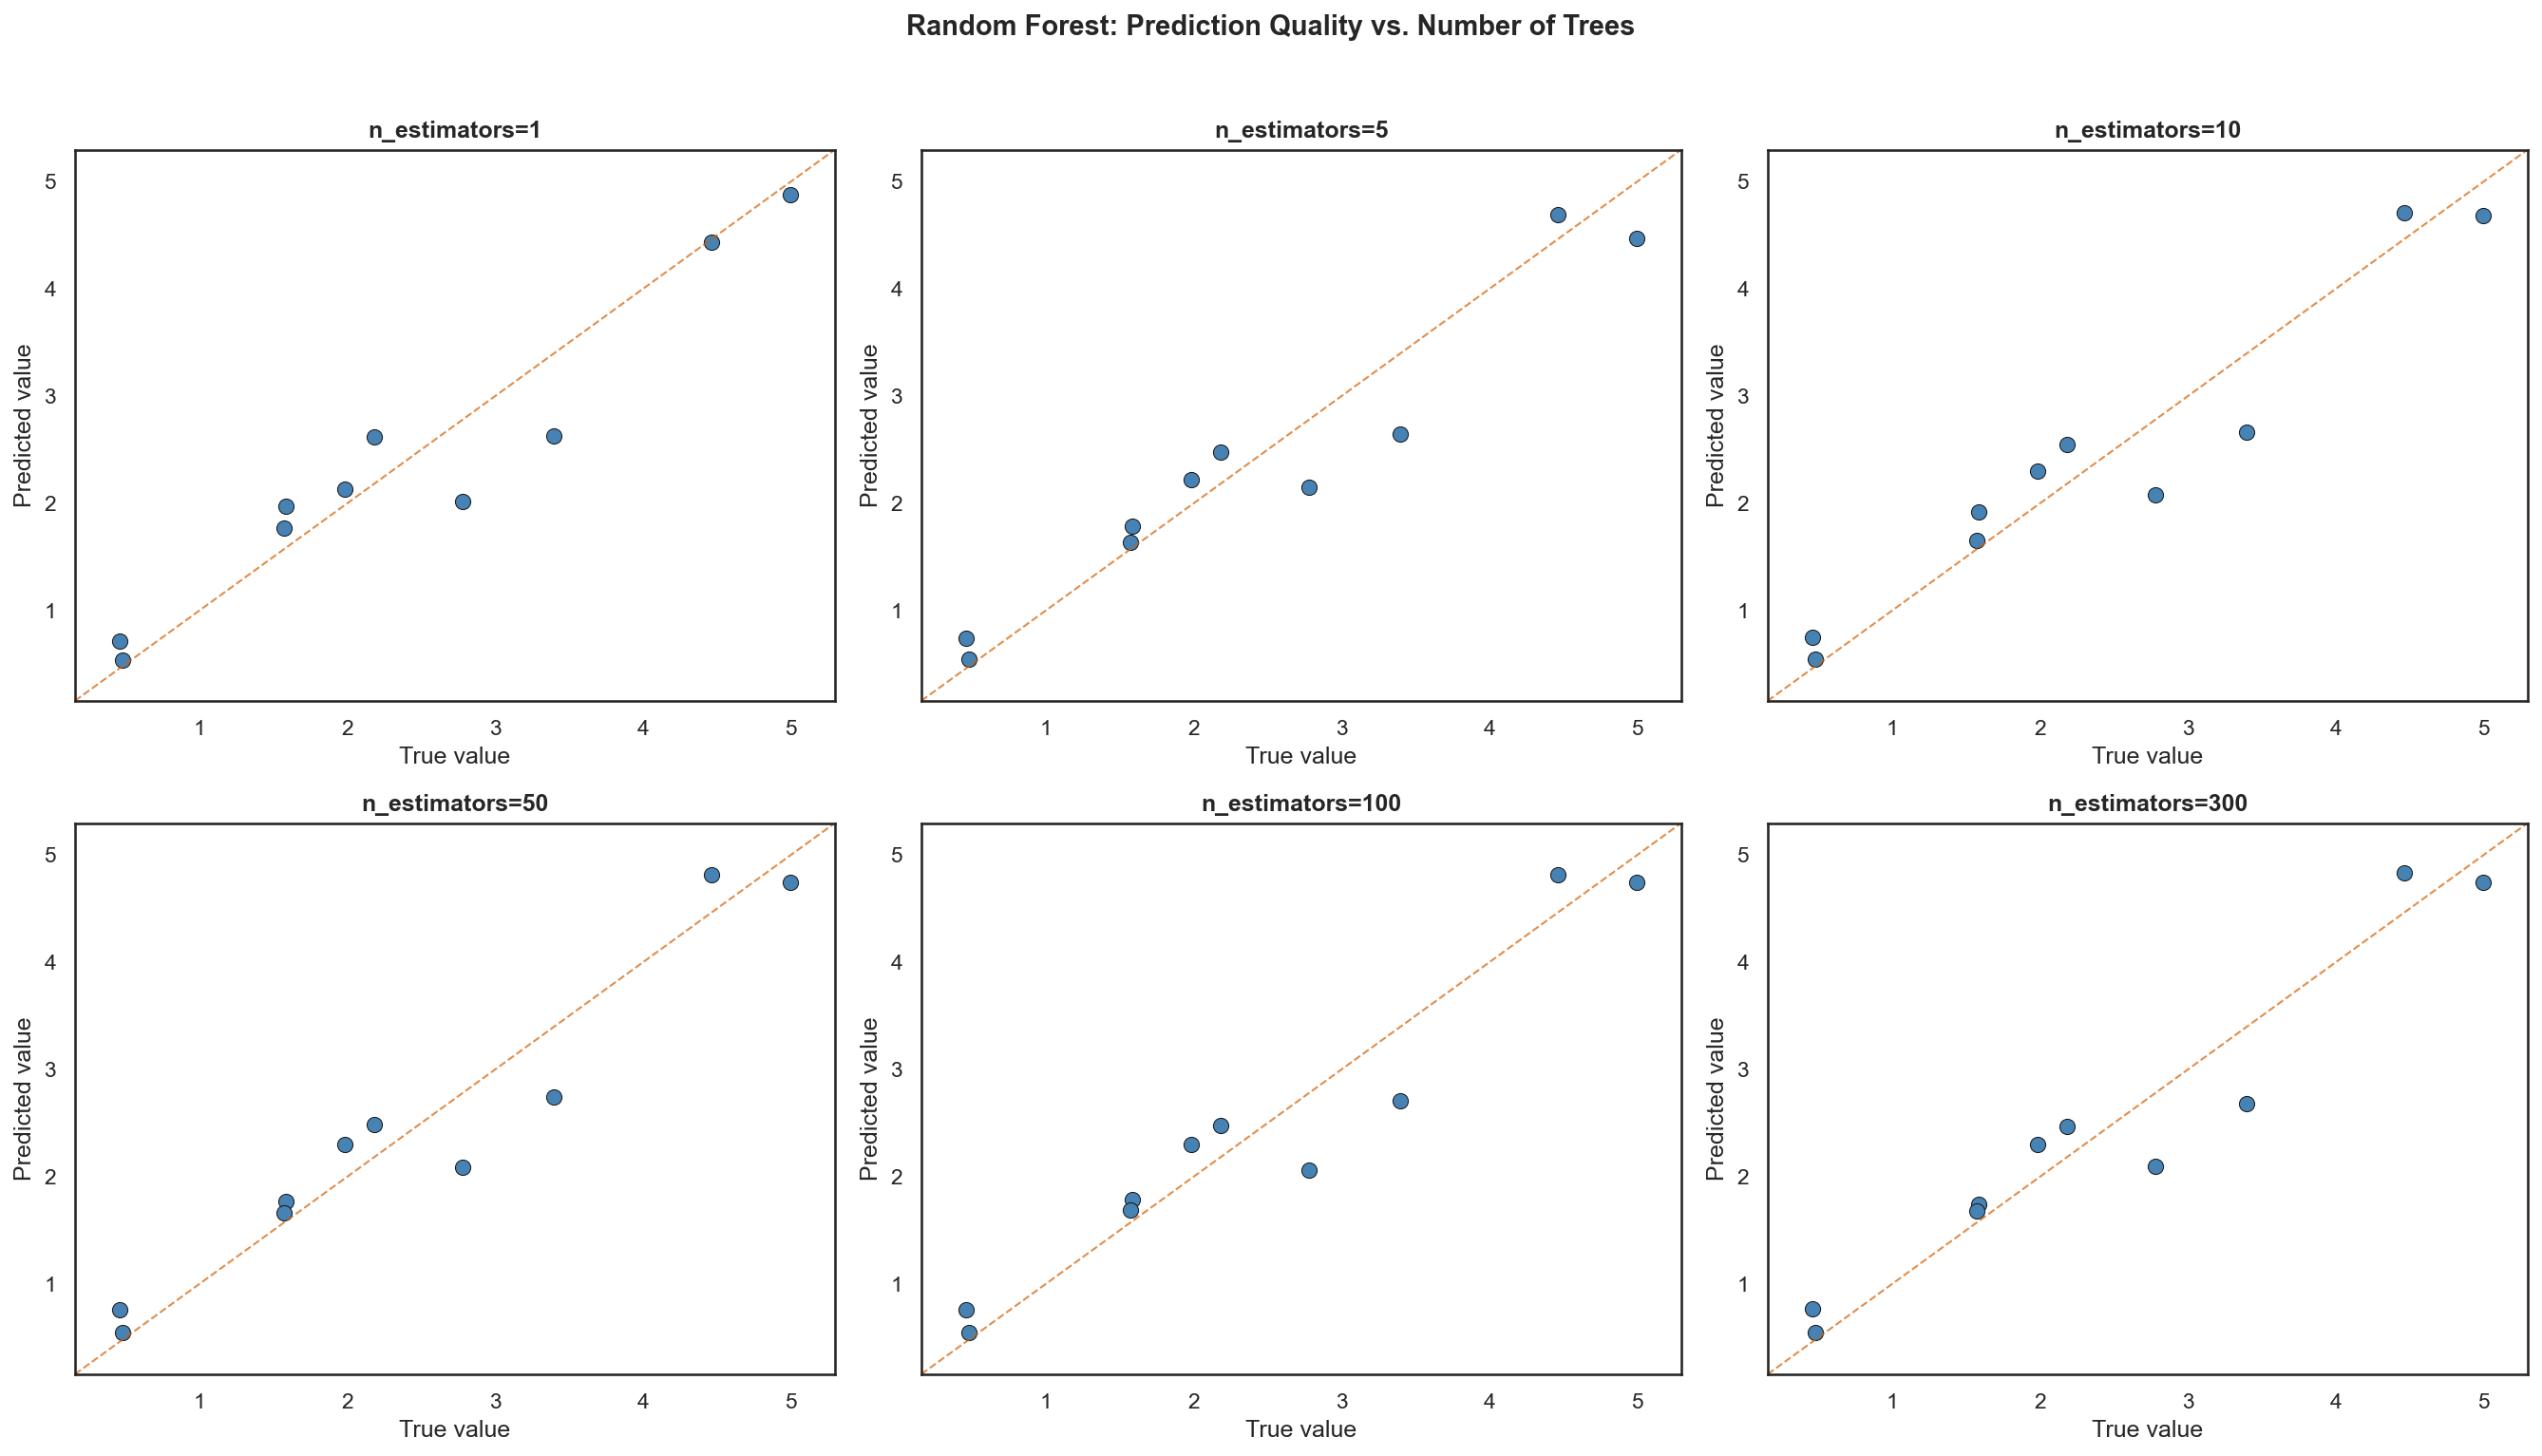

📌 With just 1 tree, predictions are noisy (high variance).
   As we add trees, predictions converge to the red diagonal.
   After ~50-100 trees, adding more barely changes anything — diminishing returns.


In [9]:
# Effect of n_estimators on prediction stability
n_trees_list = [1, 5, 10, 50, 100, 300]

# Use 10 random samples to show variance
sample_indices = np.random.RandomState(42).choice(len(X), 10, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, n_trees in zip(axes.ravel(), n_trees_list):
    model = RandomForestRegressor(n_estimators=n_trees, max_depth=10, random_state=42)
    model.fit(X, y)

    preds = model.predict(X[sample_indices])
    true_vals = y[sample_indices]

    ax.scatter(true_vals, preds, color="steelblue", s=60, edgecolors="k", linewidths=0.5)
    lims = [min(true_vals.min(), preds.min()) - 0.3, max(true_vals.max(), preds.max()) + 0.3]
    ax.plot(lims, lims, "r--", linewidth=1, alpha=0.7)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("True value")
    ax.set_ylabel("Predicted value")
    ax.set_title(f"n_estimators={n_trees}", fontweight="bold")

fig.suptitle("Random Forest: Prediction Quality vs. Number of Trees", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("📌 With just 1 tree, predictions are noisy (high variance).")
print("   As we add trees, predictions converge to the red diagonal.")
print("   After ~50-100 trees, adding more barely changes anything — diminishing returns.")

### 9.2 XGBoost: `learning_rate` (Shrinkage)

The `learning_rate` controls how much each tree contributes. The prediction at round $t$ is:

$$F_t(x) = F_{t-1}(x) + \eta \cdot h_t(x)$$

where $\eta$ is the learning rate and $h_t(x)$ is the new tree. A **smaller learning rate** means each tree contributes less, so more trees are needed — but the model is often more robust.

Let's see this tradeoff:

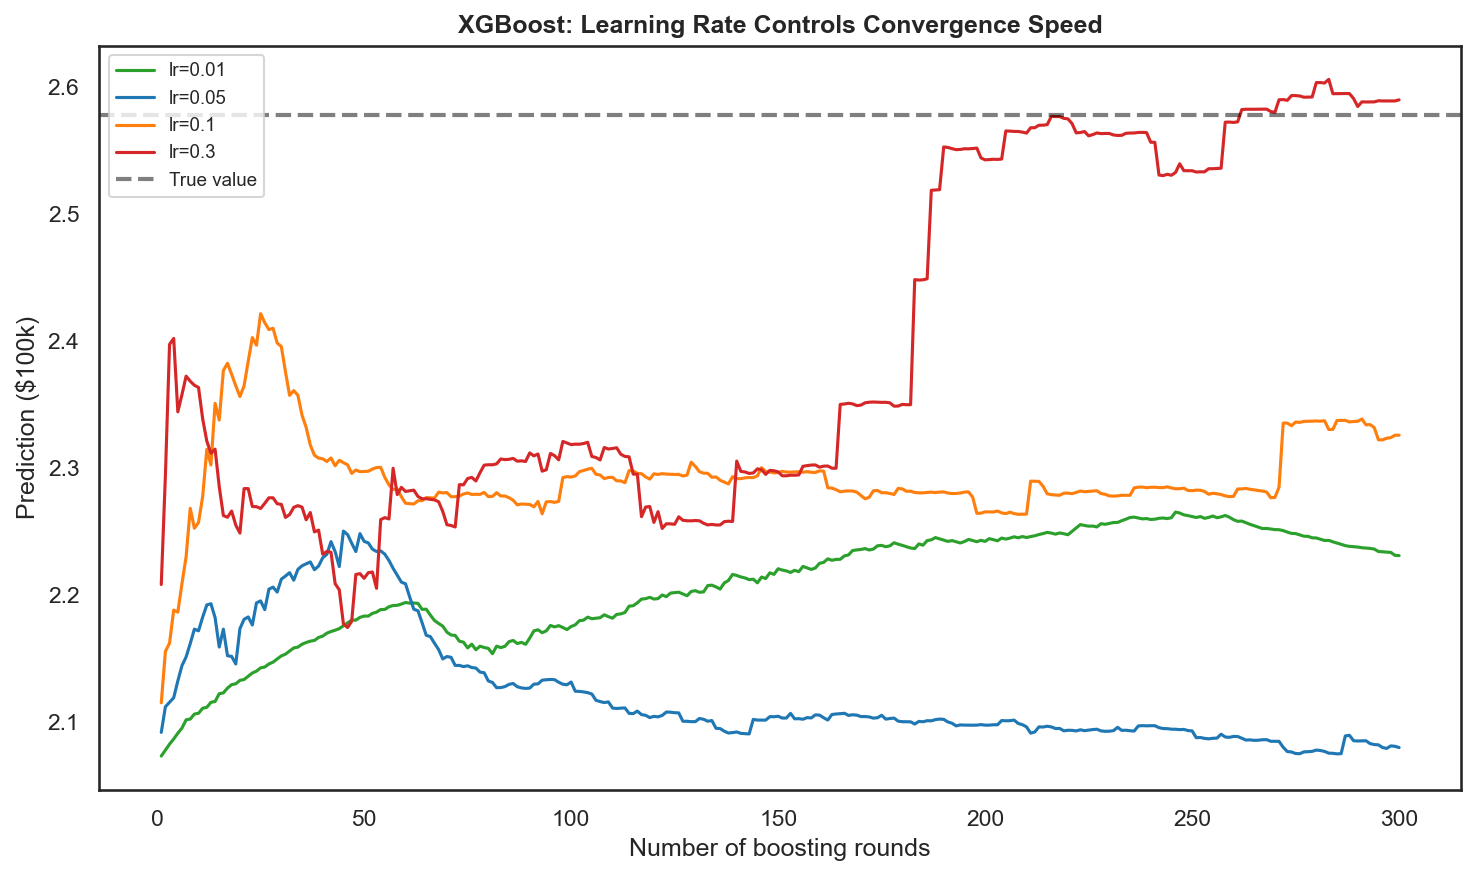

📌 High learning_rate (red): Converges fast but may overshoot.
   Low learning_rate (green): Converges slowly but more smoothly.
   In practice: Use a small learning_rate (0.01–0.1) with more trees.
   This is the standard advice — 'slow and steady' gives better generalization.


In [10]:
# Effect of learning_rate on convergence
learning_rates = [0.01, 0.05, 0.1, 0.3]
sample = X[sample_idx:sample_idx+1]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2ca02c", "#1f77b4", "#ff7f0e", "#d62728"]

for lr, color in zip(learning_rates, colors):
    model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=lr, random_state=42)
    model.fit(X, y)

    preds = [model.predict(sample, iteration_range=(0, n))[0] for n in range(1, 301)]
    ax.plot(range(1, 301), preds, color=color, linewidth=1.5, label=f"lr={lr}")

ax.axhline(y=true_val, color="black", linestyle="--", linewidth=2, alpha=0.5, label="True value")
ax.set_xlabel("Number of boosting rounds")
ax.set_ylabel("Prediction ($100k)")
ax.set_title("XGBoost: Learning Rate Controls Convergence Speed", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("📌 High learning_rate (red): Converges fast but may overshoot.")
print("   Low learning_rate (green): Converges slowly but more smoothly.")
print("   In practice: Use a small learning_rate (0.01–0.1) with more trees.")
print("   This is the standard advice — 'slow and steady' gives better generalization.")

### 9.3 The Opposite Depth Strategies

Notice a crucial difference:
- **Random Forest** uses **deep trees** (`max_depth=None` or large) — each tree has low bias but high variance. Averaging reduces the variance.
- **XGBoost** uses **shallow trees** (`max_depth=3–6`) — each tree has high bias but low variance. Sequential correction reduces the bias.

This connects directly to the theory:

| | Bagging (RF) | Boosting (XGBoost) |
|---|---|---|
| **Goal** | Reduce Variance | Reduce Bias |
| **Base Models** | Deep trees (complex) | Shallow trees (simple) |
| **Training** | Parallel | Sequential |

Let's demonstrate this by varying `max_depth` for both:

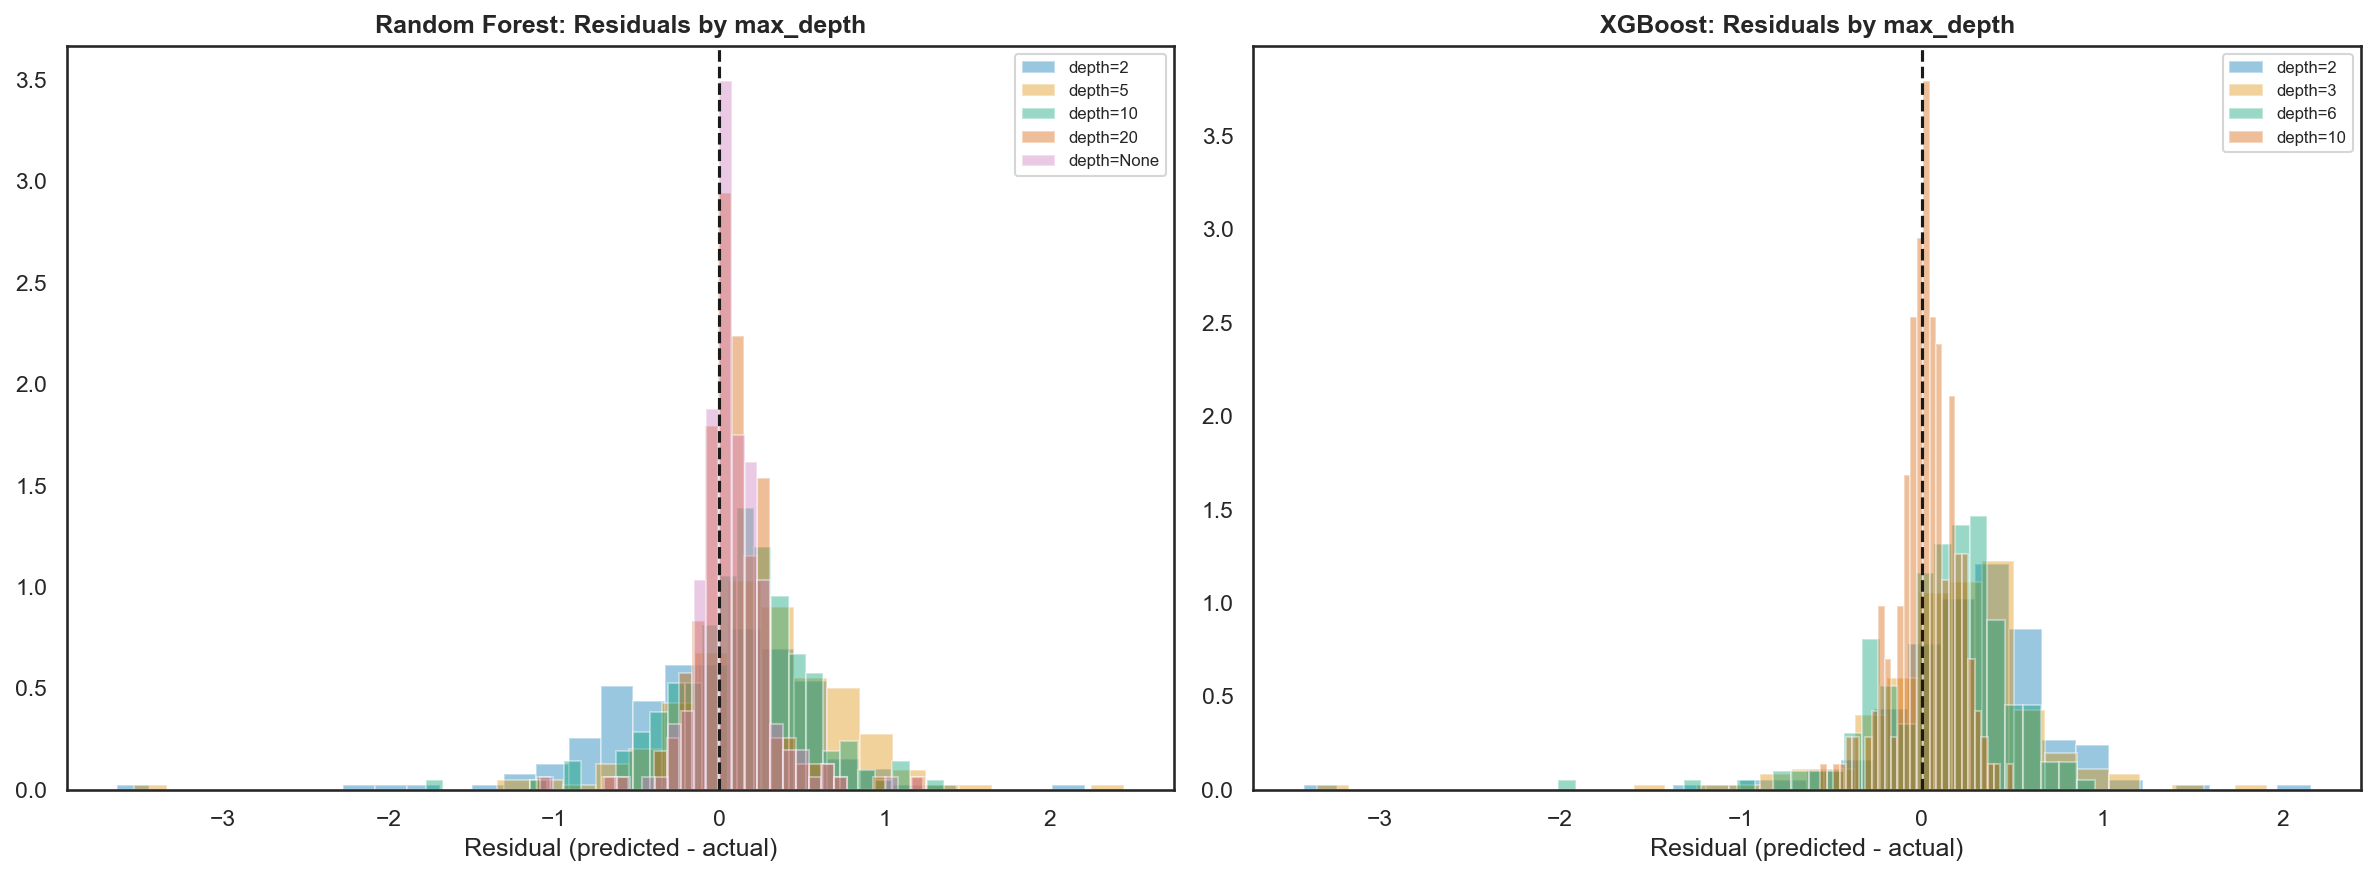

📌 RF: Deeper trees → tighter residuals (less bias), but RF naturally controls variance via averaging.
   XGBoost: Even shallow trees (depth=3) produce tight residuals, because boosting corrects errors.
   XGBoost with very deep trees risks overfitting — the sequential correction amplifies noise.


In [11]:
depths = [2, 5, 10, 20, None]  # None = unlimited
depth_labels = [str(d) if d is not None else "None" for d in depths]

# For a handful of samples, compare predictions across depths
n_test = 200
X_sub = X[:n_test]
y_sub = y[:n_test]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest: varies max_depth
for depth, label in zip(depths, depth_labels):
    rf_d = RandomForestRegressor(n_estimators=50, max_depth=depth, random_state=42)
    rf_d.fit(X, y)
    preds = rf_d.predict(X_sub)
    residuals = preds - y_sub
    axes[0].hist(residuals, bins=30, alpha=0.4, label=f"depth={label}", density=True)

axes[0].set_title("Random Forest: Residuals by max_depth", fontweight="bold")
axes[0].set_xlabel("Residual (predicted - actual)")
axes[0].legend(fontsize=8)
axes[0].axvline(0, color="k", linestyle="--")

# XGBoost: varies max_depth (only integer depths)
xgb_depths = [2, 3, 6, 10]
for depth in xgb_depths:
    xgb_d = XGBRegressor(n_estimators=100, max_depth=depth, learning_rate=0.1, random_state=42)
    xgb_d.fit(X, y)
    preds = xgb_d.predict(X_sub)
    residuals = preds - y_sub
    axes[1].hist(residuals, bins=30, alpha=0.4, label=f"depth={depth}", density=True)

axes[1].set_title("XGBoost: Residuals by max_depth", fontweight="bold")
axes[1].set_xlabel("Residual (predicted - actual)")
axes[1].legend(fontsize=8)
axes[1].axvline(0, color="k", linestyle="--")

plt.tight_layout()
plt.show()

print("📌 RF: Deeper trees → tighter residuals (less bias), but RF naturally controls variance via averaging.")
print("   XGBoost: Even shallow trees (depth=3) produce tight residuals, because boosting corrects errors.")
print("   XGBoost with very deep trees risks overfitting — the sequential correction amplifies noise.")

---

## 10. Making Predictions: How the Two Models Differ

Let's look at a scatter of predictions for both models to see how they approach the same problem:

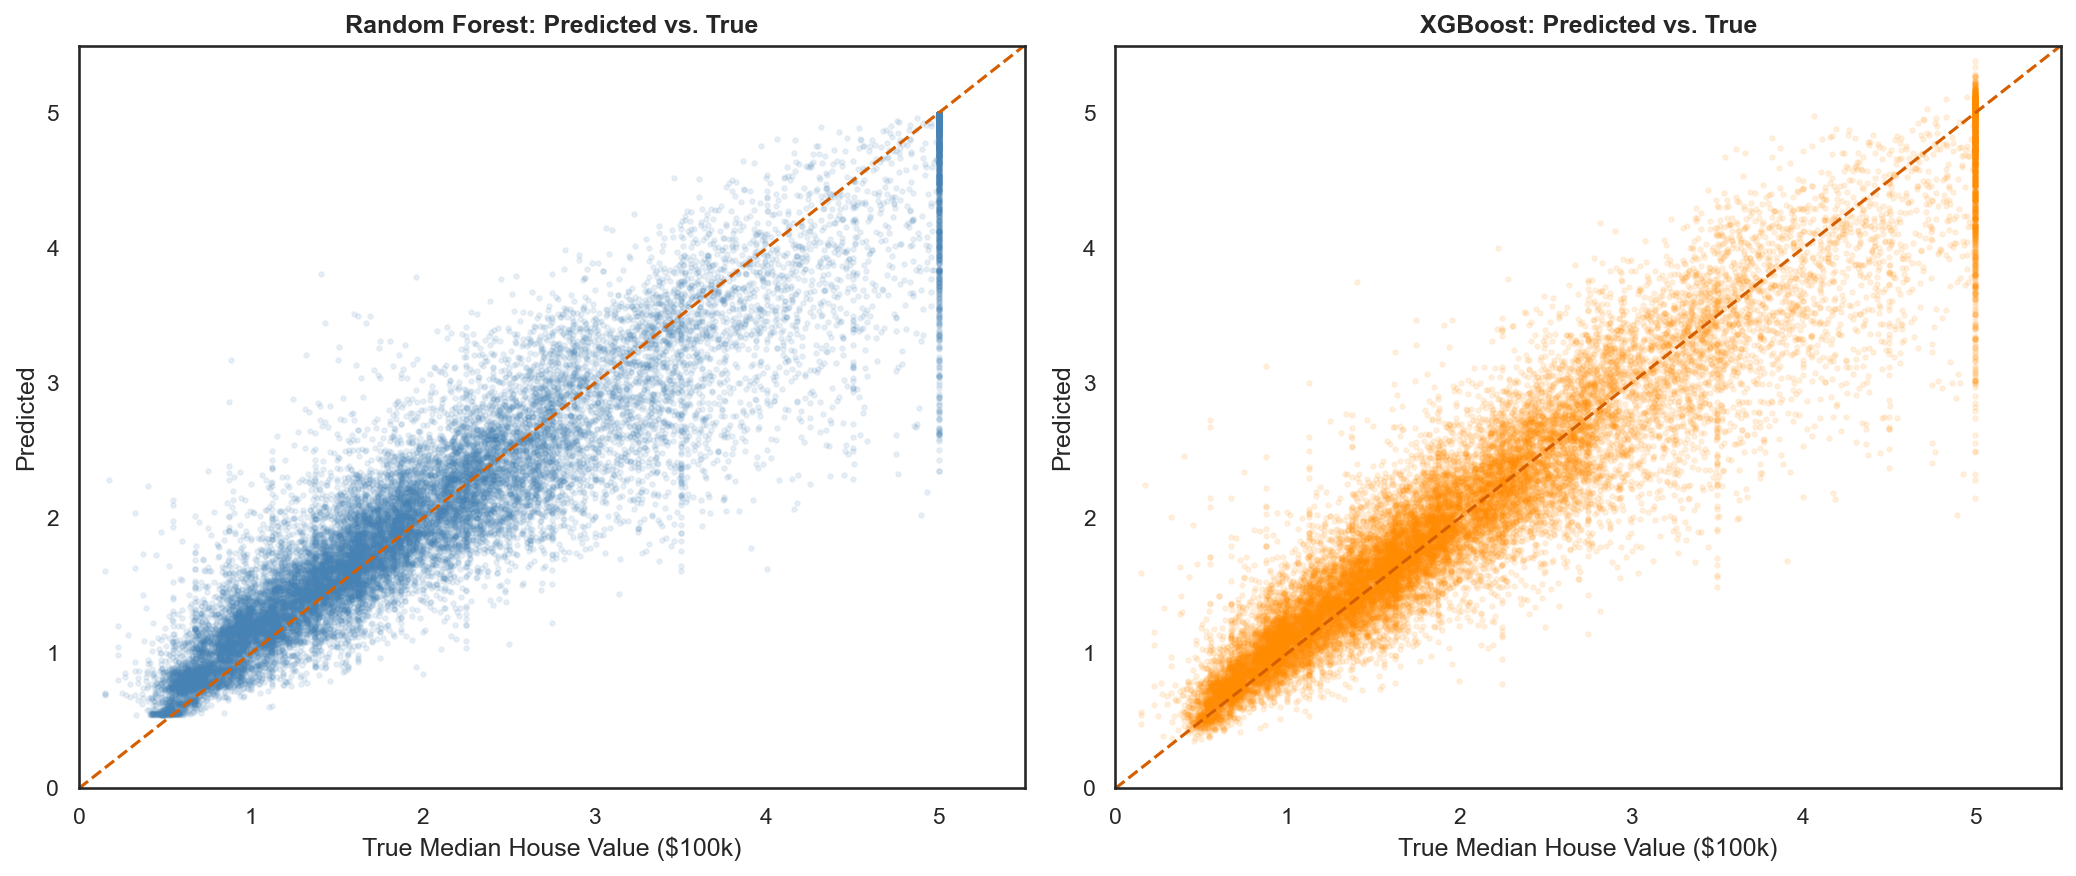

📌 Both models closely follow the red diagonal (perfect prediction line).
   Notice the ceiling at ~$500k — the target variable is capped in this dataset.
   Neither model can predict above the cap, so those points cluster at the top.


In [12]:
# Predict on the full dataset to see how well each fits
rf_preds = rf.predict(X)
xgb_preds = xgb.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, preds, name, color in zip(axes, [rf_preds, xgb_preds],
                                   ["Random Forest", "XGBoost"],
                                   ["steelblue", "darkorange"]):
    ax.scatter(y, preds, alpha=0.1, s=5, color=color)
    ax.plot([0, 5.5], [0, 5.5], "r--", linewidth=1.5)
    ax.set_xlabel("True Median House Value ($100k)")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{name}: Predicted vs. True", fontweight="bold")
    ax.set_xlim(0, 5.5)
    ax.set_ylim(0, 5.5)

plt.tight_layout()
plt.show()

print("📌 Both models closely follow the red diagonal (perfect prediction line).")
print("   Notice the ceiling at ~$500k — the target variable is capped in this dataset.")
print("   Neither model can predict above the cap, so those points cluster at the top.")

---

## 11. Spatial Predictions: Seeing the Forest for the Trees

California housing data has latitude/longitude. Let's see how well each model captures the spatial price patterns — a great visual way to understand what the models have learned:

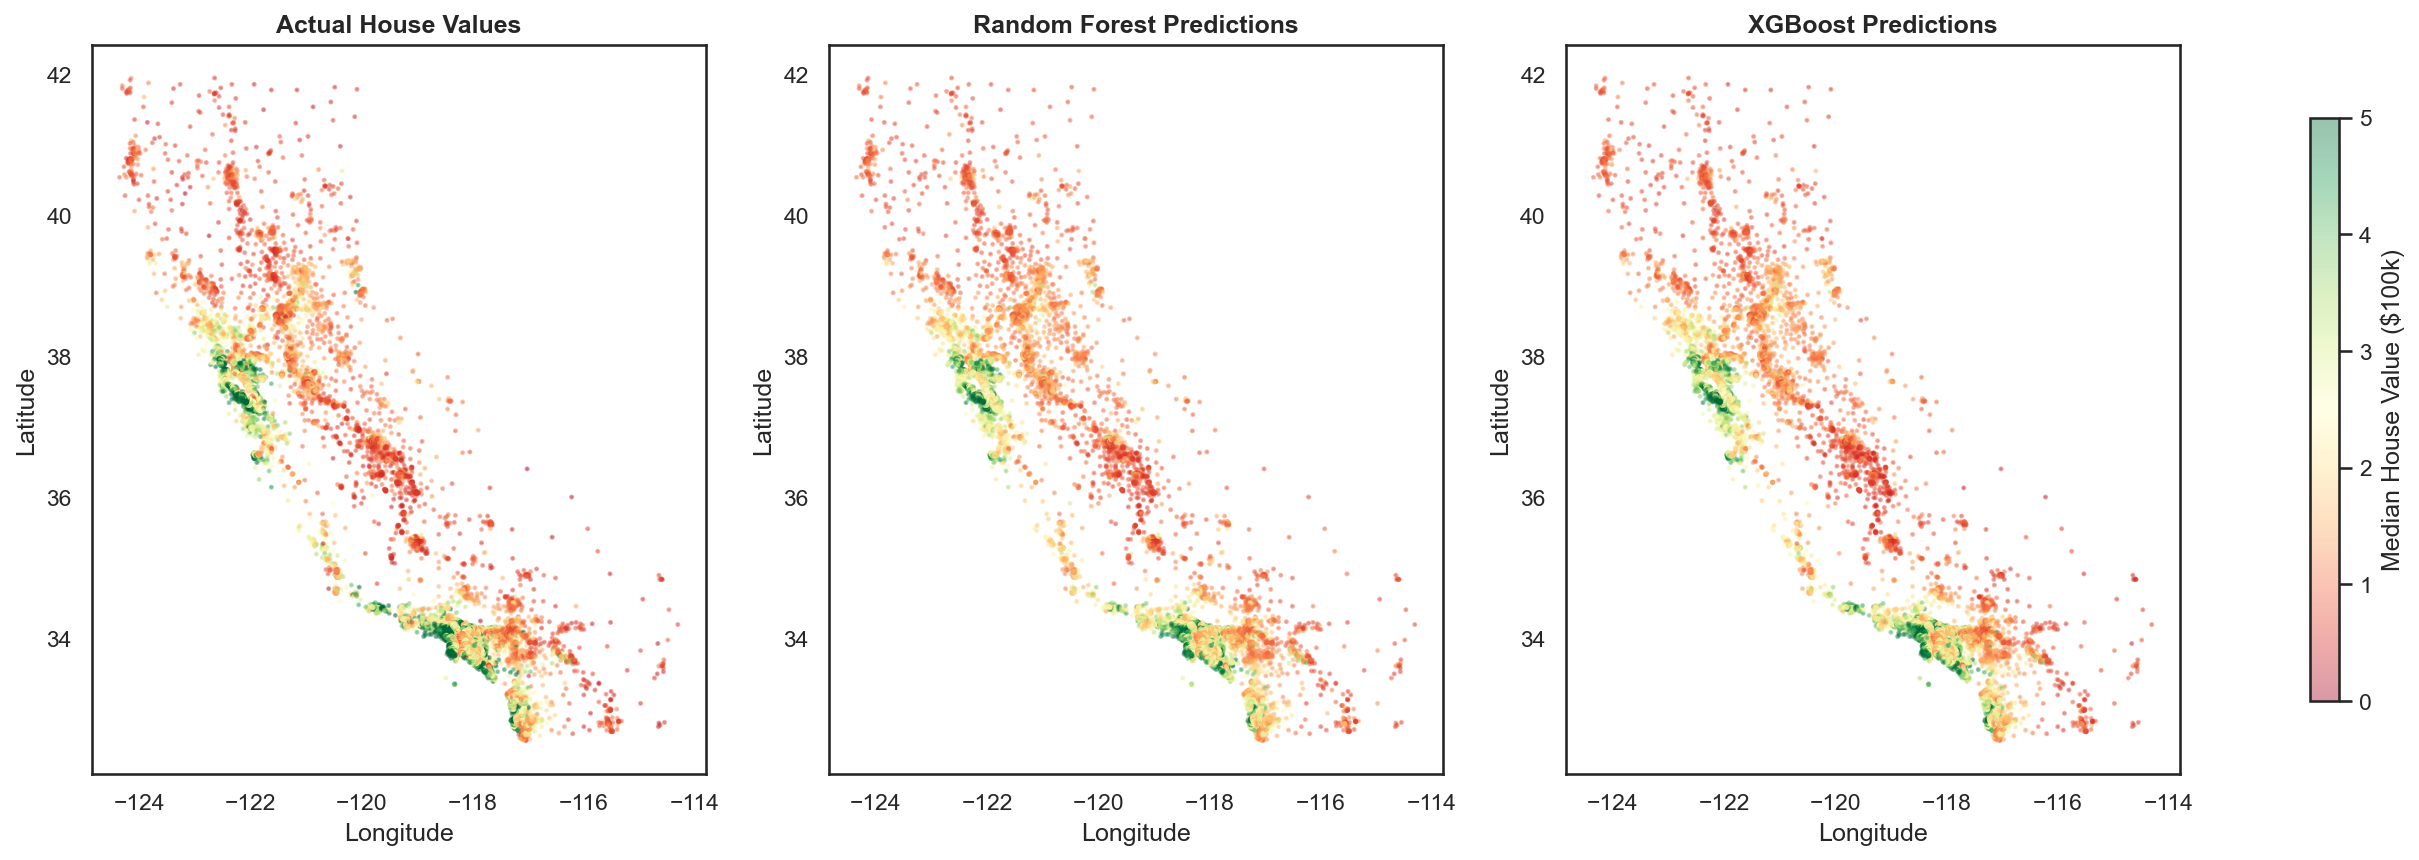

📌 Both models reproduce the coastal premium and Bay Area/LA price clusters.
   This is especially impressive because the models only see lat/long as plain numbers,
   yet the decision tree splits naturally carve out geographic regions.


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Actual values
scatter_kw = dict(c=y, cmap="RdYlGn", s=2, alpha=0.4, vmin=0, vmax=5)
axes[0].scatter(df["Longitude"], df["Latitude"], **scatter_kw)
axes[0].set_title("Actual House Values", fontweight="bold")

# RF predictions
axes[1].scatter(df["Longitude"], df["Latitude"], c=rf_preds, cmap="RdYlGn", s=2, alpha=0.4, vmin=0, vmax=5)
axes[1].set_title("Random Forest Predictions", fontweight="bold")

# XGBoost predictions
im = axes[2].scatter(df["Longitude"], df["Latitude"], c=xgb_preds, cmap="RdYlGn", s=2, alpha=0.4, vmin=0, vmax=5)
axes[2].set_title("XGBoost Predictions", fontweight="bold")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.colorbar(im, ax=axes, label="Median House Value ($100k)", shrink=0.8)
plt.show()

print("📌 Both models reproduce the coastal premium and Bay Area/LA price clusters.")
print("   This is especially impressive because the models only see lat/long as plain numbers,")
print("   yet the decision tree splits naturally carve out geographic regions.")

---

## 12. Training Speed Comparison

The theory notes that Bagging trains in parallel (independent trees) while Boosting is sequential. Let's time both:

In [15]:
import time

n_trees_test = [10, 50, 100, 200]

print(f"{'n_trees':<10} {'RF (sec)':<15} {'XGBoost (sec)':<15}")
print("-" * 40)

for n in n_trees_test:
    # Time RF
    start = time.perf_counter()
    RandomForestRegressor(n_estimators=n, max_depth=10, random_state=42).fit(X, y)
    rf_time = time.perf_counter() - start

    # Time XGBoost
    start = time.perf_counter()
    XGBRegressor(n_estimators=n, max_depth=6, learning_rate=0.1, random_state=42).fit(X, y)
    xgb_time = time.perf_counter() - start

    print(f"{n:<10} {rf_time:<15.4f} {xgb_time:<15.4f}")

print(f"\n📌 Both are fast on this dataset. XGBoost is highly optimized with")
print(f"   parallel tree building and cache-aware algorithms.")
print(f"   RF could be even faster with n_jobs=-1 (parallel tree training).")

n_trees    RF (sec)        XGBoost (sec)  
----------------------------------------
10         0.6751          0.0275         
50         3.4855          0.0931         
100        6.8565          0.1739         
200        13.2532         0.3405         

📌 Both are fast on this dataset. XGBoost is highly optimized with
   parallel tree building and cache-aware algorithms.
   RF could be even faster with n_jobs=-1 (parallel tree training).


---

## 13. Single Tree vs. Ensemble: Why Bother?

To close the loop with the Decision Trees and Regression Trees labs, let's see the difference between a single tree and the two ensembles using a simple visual. We'll fit all three on a 1D slice of the data (MedInc → MedHouseVal):

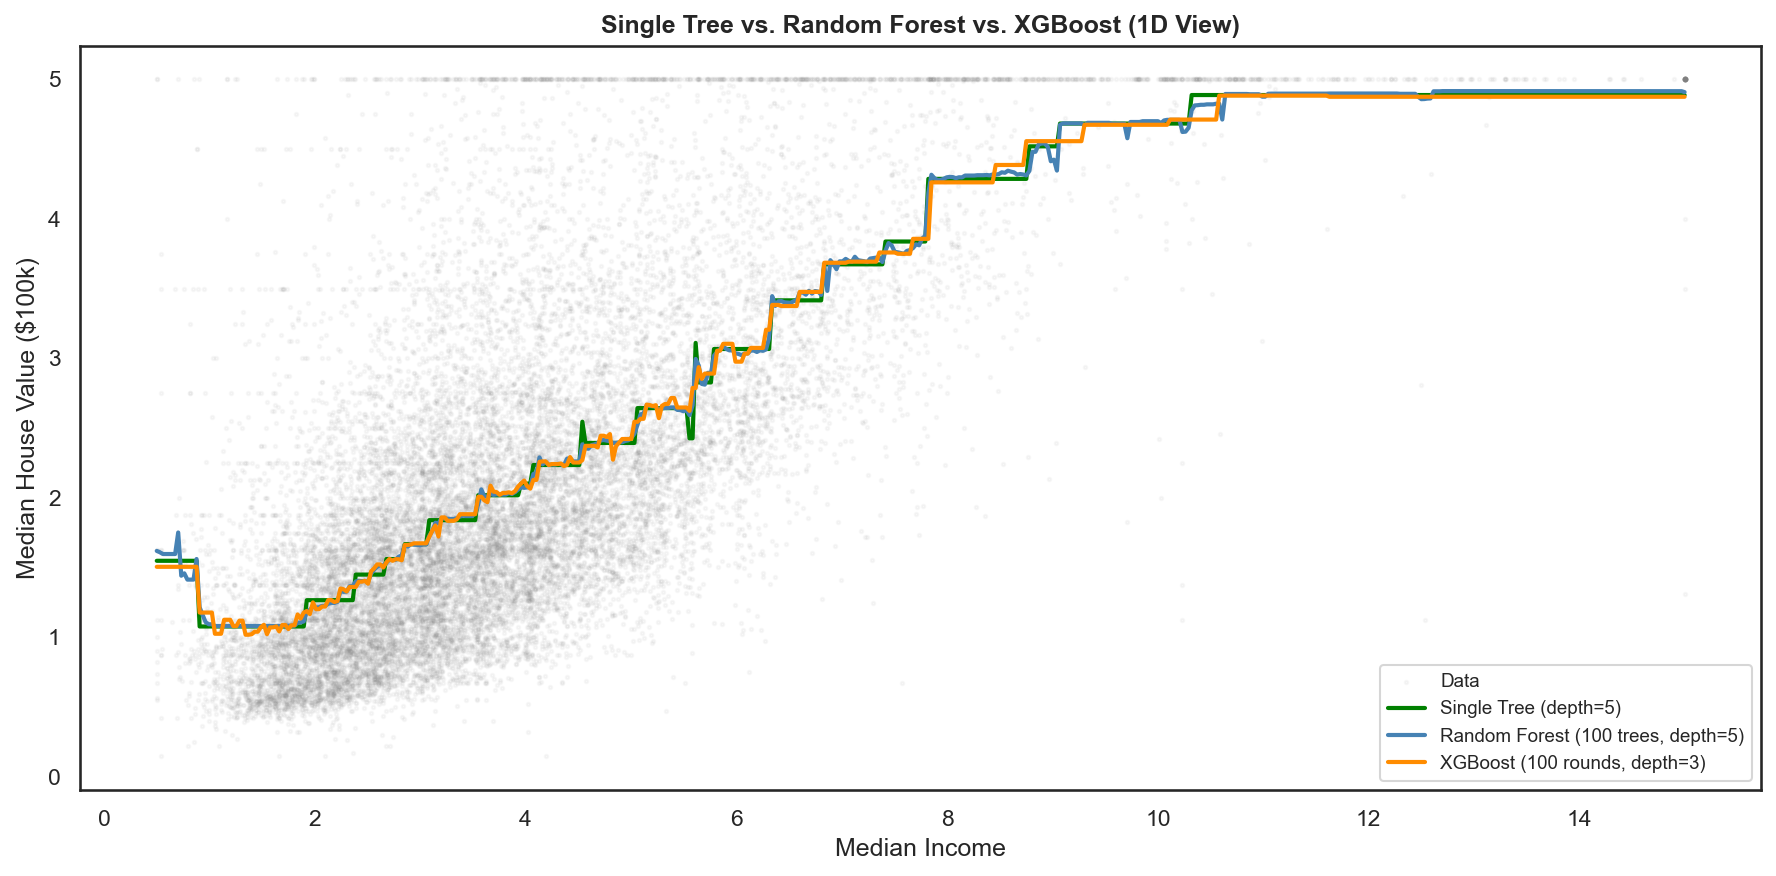

📌 Single Tree (green): Jagged step function — captures some trends but very coarse.
   Random Forest (blue): Smoother — averaging 100 different step functions
   creates a quasi-continuous curve. This is variance reduction via Bagging.
   XGBoost (orange): Also smooth, built up by sequentially correcting residuals.
   Both ensembles are much better than a single tree!


In [16]:
# Use only MedInc (strongest predictor) for 1D visualization
X_1d = X[:, 0:1]  # MedInc

# Fit three models
tree_1d = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_1d, y)
rf_1d = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42).fit(X_1d, y)
xgb_1d = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42).fit(X_1d, y)

# Create prediction grid
x_grid = np.linspace(X_1d.min(), X_1d.max(), 500).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(X_1d.ravel(), y, alpha=0.05, s=3, color="gray", label="Data")
ax.plot(x_grid, tree_1d.predict(x_grid), color="green", linewidth=2, label="Single Tree (depth=5)")
ax.plot(x_grid, rf_1d.predict(x_grid), color="steelblue", linewidth=2, label="Random Forest (100 trees, depth=5)")
ax.plot(x_grid, xgb_1d.predict(x_grid), color="darkorange", linewidth=2, label="XGBoost (100 rounds, depth=3)")

ax.set_xlabel("Median Income")
ax.set_ylabel("Median House Value ($100k)")
ax.set_title("Single Tree vs. Random Forest vs. XGBoost (1D View)", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("📌 Single Tree (green): Jagged step function — captures some trends but very coarse.")
print("   Random Forest (blue): Smoother — averaging 100 different step functions")
print("   creates a quasi-continuous curve. This is variance reduction via Bagging.")
print("   XGBoost (orange): Also smooth, built up by sequentially correcting residuals.")
print("   Both ensembles are much better than a single tree!")

---

## Summary

In this lab, we learned how to use scikit-learn's `RandomForestRegressor` and XGBoost's `XGBRegressor` for regression. Here's what we covered:

| Step | What We Did | Key API |
|------|-------------|--------|
| Load data | California Housing (20,640 samples, 8 features) | `fetch_california_housing()` |
| No scaling needed | Tree-based models use threshold splits, not distances | — |
| Build Random Forest | Bagging: 100 deep, independent trees | `RandomForestRegressor().fit(X, y)` |
| Inspect trees | Looked at individual trees inside the forest | `.estimators_`, `.tree_` |
| Ensemble effect | Showed how averaging stabilizes predictions | Running average visualization |
| Build XGBoost | Boosting: 100 shallow, sequential trees | `XGBRegressor().fit(X, y)` |
| Boosting trace | Watched predictions improve round by round | `iteration_range` parameter |
| Feature importance | Compared how RF and XGBoost rank features | `.feature_importances_` |
| `n_estimators` | More trees → more stable predictions (diminishing returns) | `n_estimators` parameter |
| `learning_rate` | Controls how fast XGBoost converges | `learning_rate` parameter |
| Depth strategies | RF=deep trees, XGBoost=shallow trees | `max_depth` parameter |
| Predictions | Predicted vs. True scatter for both models | `.predict(X)` |
| Spatial map | Visualized predictions on California map | lat/long scatter |
| Speed | Timed training for both models | `time.perf_counter()` |
| Single vs. Ensemble | Showed why ensembles beat single trees | 1D comparison plot |

The key takeaways are:

1. **Random Forest = Bagging** — trains many deep, independent trees on bootstrap samples, then averages. Reduces **variance**.
2. **XGBoost = Boosting** — trains many shallow, sequential trees where each corrects the previous. Reduces **bias**.
3. **Both produce smoother, more accurate predictions** than a single decision tree.
4. **Feature importance** comes built-in — both models tell you which features matter most.
5. **No scaling needed** — tree-based ensembles handle different feature scales natively.
6. **Key hyperparameters differ**:
   - RF: `n_estimators`, `max_depth`, `max_features`
   - XGBoost: `n_estimators`, `max_depth`, `learning_rate`, `subsample`
7. **Both are among the most powerful models** for tabular/structured data — they're the workhorses of Kaggle competitions and real-world ML.

---

This is the last lab in the Non-Linear and Ensemble Models folder. Next, we move on to [Unsupervised Learning](../04_unsupervised_learning/).